<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

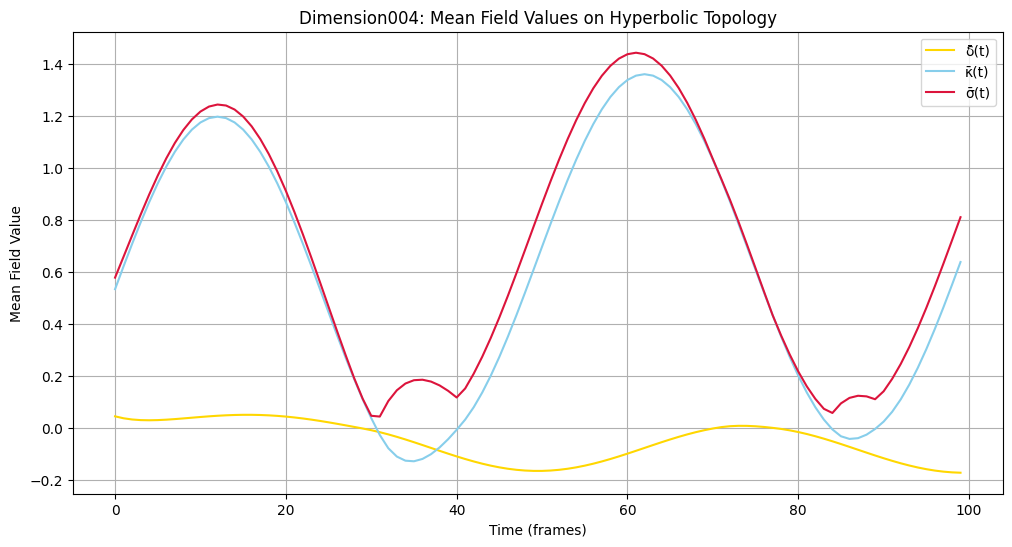

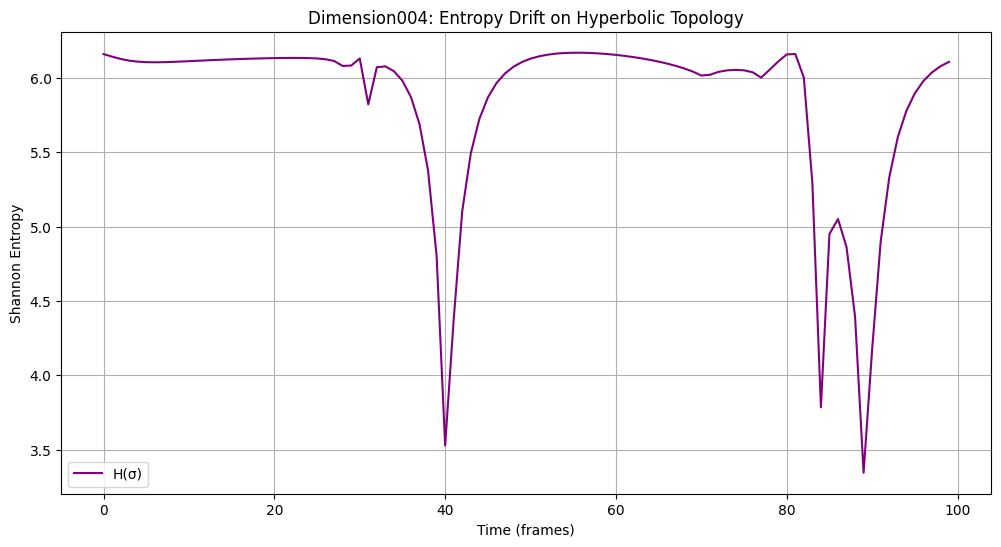

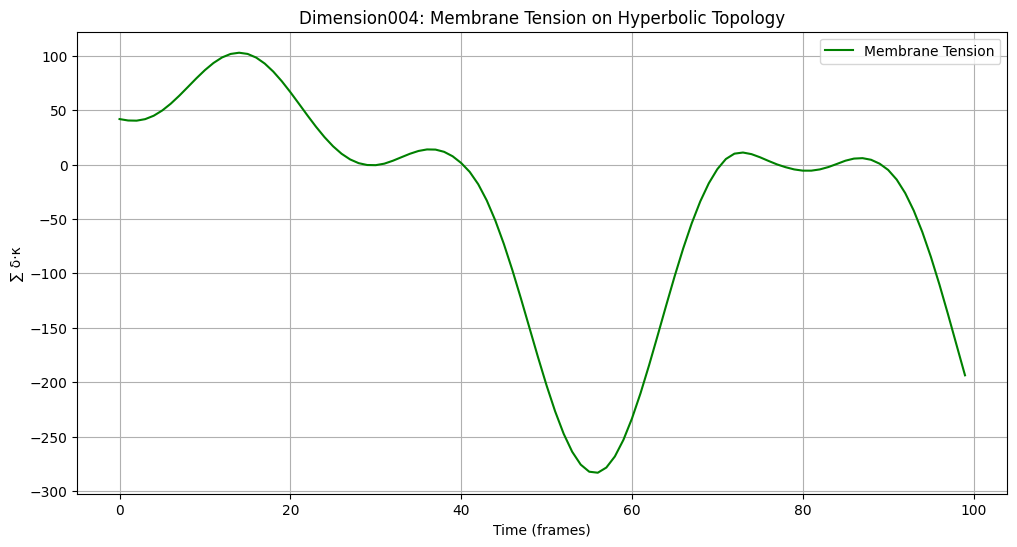

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.spatial.distance import cdist

# -------------------------------
# Hyperbolic Distance (Poincaré Disk)
# -------------------------------
def hyperbolic_distance(p1, p2):
    norm1 = np.linalg.norm(p1, axis=-1)
    norm2 = np.linalg.norm(p2, axis=-1)
    delta = np.linalg.norm(p1 - p2, axis=-1)
    numerator = 2 * delta**2
    denominator = (1 - norm1**2) * (1 - norm2**2)
    return np.arccosh(1 + numerator / denominator)

# -------------------------------
# Build Hyperbolic Network
# -------------------------------
def build_hyperbolic_network(boundary_size=8, bulk_size=64, radius=2.5):
    G = nx.Graph()
    boundary = [f"B{i}" for i in range(boundary_size)]
    bulk = [f"U{i}" for i in range(bulk_size)]
    G.add_nodes_from(boundary, region='boundary')
    G.add_nodes_from(bulk, region='bulk')

    positions = {}
    for node in boundary + bulk:
        r = np.random.rand() ** 0.5  # bias toward edge
        theta = np.random.rand() * 2 * np.pi
        x, y = r * np.cos(theta), r * np.sin(theta)
        positions[node] = np.array([x, y])
    nx.set_node_attributes(G, positions, 'pos')

    nodes = boundary + bulk
    coords = np.array([positions[n] for n in nodes])
    dist_matrix = np.zeros((len(nodes), len(nodes)))

    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if i < j:
                dist_matrix[i, j] = hyperbolic_distance(coords[i], coords[j])
                dist_matrix[j, i] = dist_matrix[i, j]

    for i, u in enumerate(nodes):
        for j, v in enumerate(nodes):
            if i < j and dist_matrix[i, j] < radius:
                G.add_edge(u, v)

    return G

# -------------------------------
# Initialization
# -------------------------------
def initialize_fields(G, delta_init=0.5, kappa_init=0.5):
    for node in G.nodes:
        region = G.nodes[node]['region']
        G.nodes[node]['delta'] = delta_init if region == 'boundary' else 0.0
        G.nodes[node]['kappa'] = kappa_init if region == 'bulk' else 0.0

# -------------------------------
# Curvature, Tension, Entropy
# -------------------------------
def compute_curvature(G):
    return {n: abs(G.nodes[n]['delta'] - G.nodes[n]['kappa']) for n in G.nodes}

def compute_membrane_tension(G):
    tension = 0.0
    for u, v in G.edges:
        d = G.nodes[u]['delta'] * G.nodes[v]['kappa']
        d += G.nodes[v]['delta'] * G.nodes[u]['kappa']
        tension += d
    return tension

def compute_entropy(values):
    values = np.array(values)
    total = np.sum(values)
    if total == 0:
        return 0.0
    probs = values / total
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

# -------------------------------
# Recursive Update
# -------------------------------
def update_fields(G, t, delta_base=1.0, kappa_base=1.0, alpha=0.9, beta=0.9, gamma=0.1):
    delta_t = delta_base * np.sin(2 * np.pi * t / 50)
    kappa_t = kappa_base * np.cos(2 * np.pi * t / 50)
    curvature = compute_curvature(G)

    for node in G.nodes:
        region = G.nodes[node]['region']
        prev_delta = G.nodes[node]['delta']
        prev_kappa = G.nodes[node]['kappa']
        sigma = curvature[node]

        if region == 'boundary':
            G.nodes[node]['delta'] = alpha * prev_delta + (1 - alpha) * delta_t - gamma * sigma
            G.nodes[node]['kappa'] = 0.0
        else:
            G.nodes[node]['kappa'] = beta * prev_kappa + (1 - beta) * kappa_t + gamma * sigma
            G.nodes[node]['delta'] = 0.0

# -------------------------------
# Run Simulation
# -------------------------------
def run_hyperbolic_simulation(frames=100):
    G = build_hyperbolic_network()
    initialize_fields(G)

    delta_means, kappa_means, sigma_means = [], [], []
    entropy_vals, tension_vals = [], []

    for t in range(frames):
        update_fields(G, t)
        delta_vals = [G.nodes[n]['delta'] for n in G.nodes]
        kappa_vals = [G.nodes[n]['kappa'] for n in G.nodes]
        sigma_vals = list(compute_curvature(G).values())

        delta_means.append(np.mean(delta_vals))
        kappa_means.append(np.mean(kappa_vals))
        sigma_means.append(np.mean(sigma_vals))
        entropy_vals.append(compute_entropy(sigma_vals))
        tension_vals.append(compute_membrane_tension(G))

    return delta_means, kappa_means, sigma_means, entropy_vals, tension_vals

# -------------------------------
# Run and Plot
# -------------------------------
results = run_hyperbolic_simulation()
frames = range(100)

plt.figure(figsize=(12, 6))
plt.plot(frames, results[0], label='δ̄(t)', color='gold')
plt.plot(frames, results[1], label='κ̄(t)', color='skyblue')
plt.plot(frames, results[2], label='σ̄(t)', color='crimson')
plt.title("Dimension004: Mean Field Values on Hyperbolic Topology")
plt.xlabel("Time (frames)")
plt.ylabel("Mean Field Value")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(frames, results[3], label='H(σ)', color='purple')
plt.title("Dimension004: Entropy Drift on Hyperbolic Topology")
plt.xlabel("Time (frames)")
plt.ylabel("Shannon Entropy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(frames, results[4], label='Membrane Tension', color='green')
plt.title("Dimension004: Membrane Tension on Hyperbolic Topology")
plt.xlabel("Time (frames)")
plt.ylabel("∑ δ·κ")
plt.legend()
plt.grid(True)
plt.show()
